# Bayesian Quadrature in Multiple Dimensions

**Goal:** Demonstrate that Bayesian Quadrature (BQ) extends naturally to 2D (and higher) integration problems, and compare its sample-efficiency against Monte Carlo in the multidimensional setting.

## Why multidimensional integration matters

In one dimension, classical quadrature rules (Simpson, Gauss-Legendre) are extremely effective — they can integrate smooth functions to machine precision with just a few dozen nodes. However, these methods suffer from the **curse of dimensionality**: a $d$-dimensional grid with $n$ points per axis requires $n^d$ total evaluations.

Monte Carlo avoids this curse because its convergence rate $O(n^{-1/2})$ is dimension-independent, but it ignores smoothness structure.

**Bayesian Quadrature** can exploit smoothness (through the kernel) while operating on scattered point sets — a combination that is especially attractive in low-to-moderate dimensions (2–10) with expensive-to-evaluate integrands.

## Notebook structure

1. Define 2D test functions with known integrals
2. Fit BQ in 2D and visualize the GP posterior surface
3. Convergence comparison: BQ vs Monte Carlo vs Grid
4. Active BQ in 2D — visualize adaptively selected points
5. Key takeaways

In [9]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("/Users/I768838/Desktop/Probabilistic-quadrature")))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from source.kernels.rbf_kernel import RBFKernel
from source.measures.gaussian_measure import GaussianMeasure
from source.measures.uniform_box_measure import UniformBoxMeasure
from source.numeric_integration.bayesian_integral.bayesian_quadrature_model.bayesian_quadrature_model import BayesianQuadratureModel
from source.numeric_integration.bayesian_integral.bayesian_quadrature_model.bayesian_quadrature_config import BQConfig
from source.numeric_integration.bayesian_integral.active_bayesian_quadrature import ActiveBQSelector
from source.numeric_integration.monte_carlo.standard_monte_carlo_integral import StandardMonteCarloIntegral
from source.functions.measured_function import MeasuredFunction

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=6, suppress=True)

## 1. Two-Dimensional Test Functions

We define three 2D integrands with increasing difficulty:

| Function | Formula | Integration measure | True integral |
|----------|---------|--------------------|--------------|
| **Smooth Gaussian bump** | $f_1(x,y) = \exp(-(x^2+y^2))$ | $\mathrm{Uniform}([-2,2]^2)$ | $\frac{\pi}{16}$ |
| **Product-cosine** | $f_2(x,y) = \cos(x)\cos(y)$ | $\mathcal{N}(\mathbf{0}, I_2)$ | $e^{-1}$ |
| **Oscillatory saddle** | $f_3(x,y) = \sin(x+y)\cos(x-y)$ | $\mathrm{Uniform}([-\pi,\pi]^2)$ | $0$ (by symmetry) |

### Ground-truth derivations

- **$f_1$:** Under $\text{Uniform}([-2,2]^2)$, $\mathbb{E}[f_1] = \frac{1}{16}\int_{-2}^{2}\int_{-2}^{2} e^{-(x^2+y^2)}\,dx\,dy \approx \frac{\pi}{16}$ (the truncation error is negligible since $e^{-4} \approx 0.018$).
- **$f_2$:** $\mathbb{E}[\cos(X)\cos(Y)] = \mathbb{E}[\cos(X)]^2 = (e^{-1/2})^2 = e^{-1}$ (independence + known moment generating function of the normal distribution).
- **$f_3$:** The integrand is odd-symmetric, so the expectation under any symmetric measure is zero.

In [10]:
def f1_gauss_bump(X):
    """exp(-(x^2+y^2)), expects (n,2) array."""
    X = np.atleast_2d(X)
    return np.exp(-(X[:, 0] ** 2 + X[:, 1] ** 2))

def f2_product_cos(X):
    """cos(x)*cos(y), expects (n,2) array."""
    X = np.atleast_2d(X)
    return np.cos(X[:, 0]) * np.cos(X[:, 1])

def f3_oscillatory(X):
    """sin(x+y)*cos(x-y), expects (n,2) array."""
    X = np.atleast_2d(X)
    return np.sin(X[:, 0] + X[:, 1]) * np.cos(X[:, 0] - X[:, 1])

from scipy.special import erf
TRUE_F1 = (np.sqrt(np.pi) * erf(2) / 2) ** 2 / 16.0  # exact with truncation at [-2,2]
TRUE_F2 = np.exp(-1.0)
TRUE_F3 = 0.0

measure_uniform_2d = UniformBoxMeasure(lower=np.array([-2.0, -2.0]), upper=np.array([2.0, 2.0]))
measure_gauss_2d = GaussianMeasure(mean=np.zeros(2), cov=np.eye(2))
measure_uniform_pi = UniformBoxMeasure(lower=np.array([-np.pi, -np.pi]), upper=np.array([np.pi, np.pi]))

test_cases = [
    ('Gaussian bump', f1_gauss_bump, measure_uniform_2d, TRUE_F1),
    ('Product-cosine', f2_product_cos, measure_gauss_2d, TRUE_F2),
    ('Oscillatory saddle', f3_oscillatory, measure_uniform_pi, TRUE_F3),
]

for name, _, _, truth in test_cases:
    print(f"{name:25s}  true integral = {truth:.8f}")

Gaussian bump              true integral = 0.04862922
Product-cosine             true integral = 0.36787944
Oscillatory saddle         true integral = 0.00000000


## 2. Visualizing the True Functions

Before fitting any model, it helps to see what the integrands look like. Below are surface plots of all three test functions.

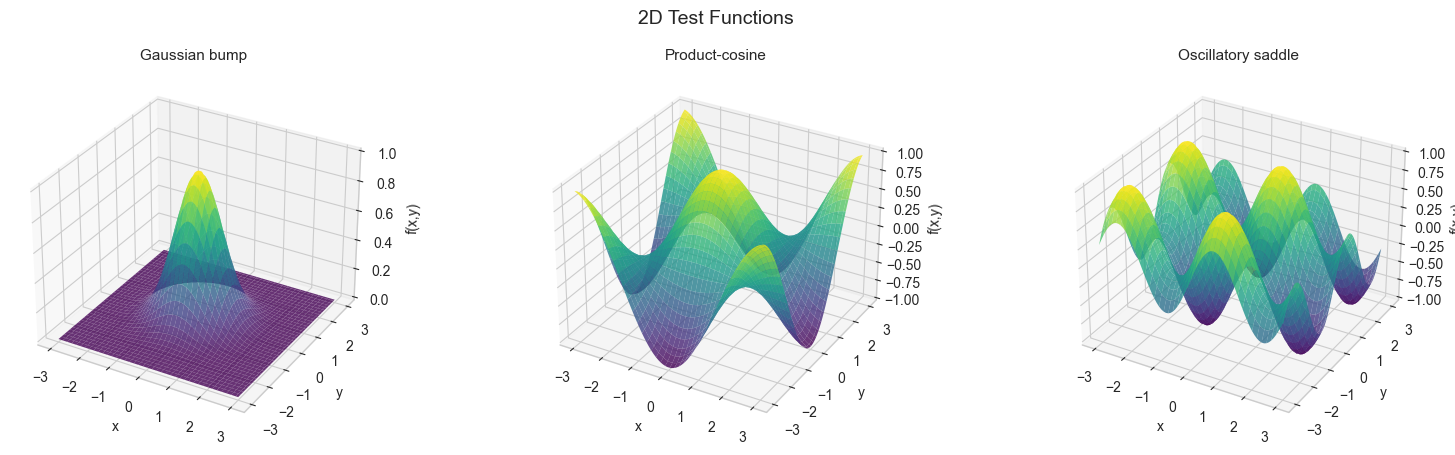

In [11]:
fig = plt.figure(figsize=(16, 4.5))

grid_1d = np.linspace(-3, 3, 80)
xx, yy = np.meshgrid(grid_1d, grid_1d)
XY = np.column_stack([xx.ravel(), yy.ravel()])

for idx, (name, func, _, _) in enumerate(test_cases):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    zz = func(XY).reshape(xx.shape)
    ax.plot_surface(xx, yy, zz, cmap=cm.viridis, alpha=0.8, linewidth=0, antialiased=True)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('f(x,y)')

plt.suptitle('2D Test Functions', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Fitting BQ in 2D — Posterior Surface

We fit a `BayesianQuadratureModel` with an RBF kernel to the Gaussian bump function using 25 random points. We then plot:

- **True function surface** (left)
- **GP posterior mean surface** (center)
- **GP posterior standard deviation** as a heatmap (right)

This shows how the GP captures the shape of the integrand and where it remains uncertain.

BQ integral estimate: 0.172774
BQ posterior std:     0.049771
True integral:        0.048629
Absolute error:       0.124145


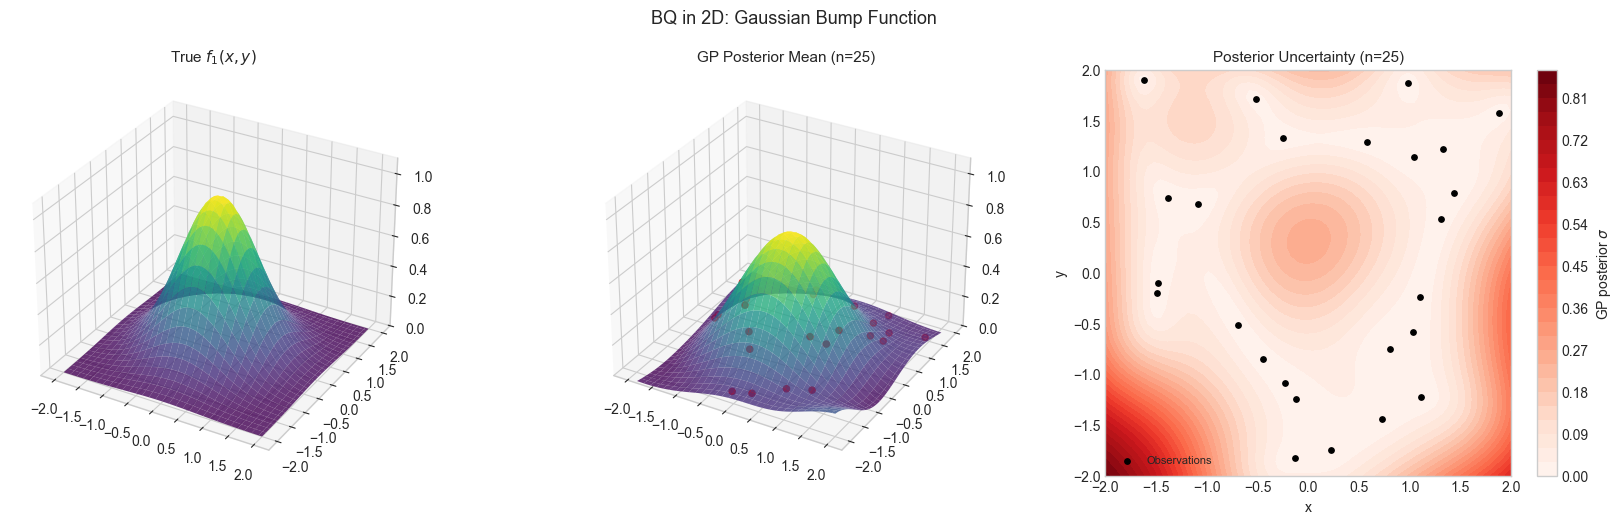

In [12]:
rng = np.random.default_rng(42)
n_train = 25

X_train = rng.uniform(-2, 2, size=(n_train, 2))
y_train = f1_gauss_bump(X_train)

kernel_2d = RBFKernel(lengthscale=1.0, variance=1.0)
config_2d = BQConfig(noise=0.0, jitter=1e-8, mc_samples_mean=4096, mc_samples_var=8192)

model_2d = BayesianQuadratureModel(kernel_2d, measure_uniform_2d, config=config_2d)
model_2d.fit(X_train, y_train)

mean_F, var_F = model_2d.integral_posterior()
print(f"BQ integral estimate: {mean_F:.6f}")
print(f"BQ posterior std:     {np.sqrt(max(var_F, 0)):.6f}")
print(f"True integral:        {TRUE_F1:.6f}")
print(f"Absolute error:       {abs(mean_F - TRUE_F1):.6f}")

grid_fine = np.linspace(-2, 2, 60)
xx_f, yy_f = np.meshgrid(grid_fine, grid_fine)
XY_fine = np.column_stack([xx_f.ravel(), yy_f.ravel()])

gp_mean, gp_var = model_2d.predict(XY_fine)
gp_std = np.sqrt(np.maximum(gp_var, 0.0))

zz_true = f1_gauss_bump(XY_fine).reshape(xx_f.shape)
zz_mean = gp_mean.reshape(xx_f.shape)
zz_std = gp_std.reshape(xx_f.shape)

fig = plt.figure(figsize=(17, 5))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot_surface(xx_f, yy_f, zz_true, cmap=cm.viridis, alpha=0.8, linewidth=0)
ax1.set_title(r'True $f_1(x,y)$', fontsize=11)
ax1.set_zlim(0, 1.1)

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.plot_surface(xx_f, yy_f, zz_mean, cmap=cm.viridis, alpha=0.8, linewidth=0)
ax2.scatter(X_train[:, 0], X_train[:, 1], y_train, c='red', s=20, zorder=5)
ax2.set_title(f'GP Posterior Mean (n={n_train})', fontsize=11)
ax2.set_zlim(0, 1.1)

ax3 = fig.add_subplot(1, 3, 3)
c = ax3.contourf(xx_f, yy_f, zz_std, levels=30, cmap='Reds')
ax3.scatter(X_train[:, 0], X_train[:, 1], c='black', s=15, zorder=5, label='Observations')
plt.colorbar(c, ax=ax3, label=r'GP posterior $\sigma$')
ax3.set_title(f'Posterior Uncertainty (n={n_train})', fontsize=11)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.legend(fontsize=8)
ax3.set_aspect('equal')

plt.suptitle('BQ in 2D: Gaussian Bump Function', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Convergence Comparison: BQ vs Monte Carlo

We now systematically compare the integration error of BQ and standard Monte Carlo as the evaluation budget $n$ increases. For each budget, we:

- **BQ**: sample $n$ points from the measure, fit the model, and record the posterior integral mean.
- **MC**: sample $n$ points from the measure, compute the sample average.

We repeat each experiment over multiple seeds to estimate the mean and spread of the error.

### Expected behavior

- For **smooth functions** (like the Gaussian bump), BQ should outperform MC at small-to-moderate budgets because it exploits the smoothness via the kernel.
- For **oscillatory functions**, BQ's advantage depends on how well the kernel matches the integrand structure.
- At very large budgets, MC eventually catches up because its $O(n^{-1/2})$ rate is robust, while BQ's numerical overhead grows.

In [13]:
budgets = [5, 10, 20, 40, 60, 80, 100, 150]
n_seeds = 15

def run_convergence(func, measure, true_val, kernel_ls=1.0, kernel_var=1.0):
    bq_errors = {n: [] for n in budgets}
    mc_errors = {n: [] for n in budgets}

    for seed in range(n_seeds):
        rng = np.random.default_rng(seed)
        X_all = measure.sample(max(budgets), rng=rng)
        y_all = func(X_all)

        for n in budgets:
            # Monte Carlo
            mc_est = float(np.mean(y_all[:n]))
            mc_errors[n].append(abs(mc_est - true_val))

            # Bayesian Quadrature
            try:
                k = RBFKernel(lengthscale=kernel_ls, variance=kernel_var)
                cfg = BQConfig(noise=0.0, jitter=1e-7, mc_samples_mean=2048, mc_samples_var=4096)
                m = BayesianQuadratureModel(k, measure, config=cfg)
                m.fit(X_all[:n], y_all[:n])
                bq_mean, _ = m.integral_posterior()
                bq_errors[n].append(abs(bq_mean - true_val))
            except Exception:
                bq_errors[n].append(np.nan)

    return bq_errors, mc_errors

results = {}
for name, func, measure, truth in test_cases:
    print(f"Running convergence for: {name}")
    bq_e, mc_e = run_convergence(func, measure, truth)
    results[name] = (bq_e, mc_e)

print("Done.")

Running convergence for: Gaussian bump
Running convergence for: Product-cosine
Running convergence for: Oscillatory saddle
Done.


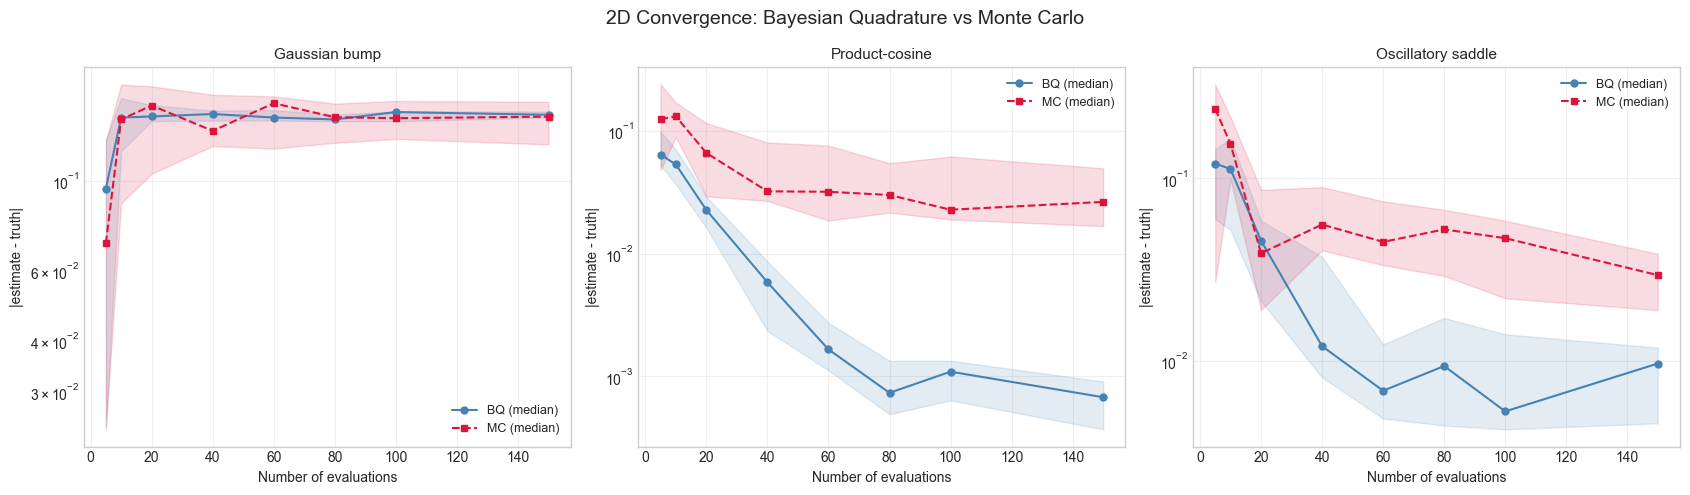

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for idx, (name, func, measure, truth) in enumerate(test_cases):
    bq_e, mc_e = results[name]
    ax = axes[idx]

    bq_median = [np.nanmedian(bq_e[n]) for n in budgets]
    bq_q25 = [np.nanpercentile(bq_e[n], 25) for n in budgets]
    bq_q75 = [np.nanpercentile(bq_e[n], 75) for n in budgets]

    mc_median = [np.nanmedian(mc_e[n]) for n in budgets]
    mc_q25 = [np.nanpercentile(mc_e[n], 25) for n in budgets]
    mc_q75 = [np.nanpercentile(mc_e[n], 75) for n in budgets]

    ax.semilogy(budgets, bq_median, 'o-', color='steelblue', lw=1.5, ms=5, label='BQ (median)')
    ax.fill_between(budgets, bq_q25, bq_q75, alpha=0.15, color='steelblue')
    ax.semilogy(budgets, mc_median, 's--', color='crimson', lw=1.5, ms=5, label='MC (median)')
    ax.fill_between(budgets, mc_q25, mc_q75, alpha=0.15, color='crimson')

    ax.set_xlabel('Number of evaluations')
    ax.set_ylabel('|estimate - truth|')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('2D Convergence: Bayesian Quadrature vs Monte Carlo', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Active BQ in 2D — Adaptive Point Selection

Active Bayesian Quadrature chooses each new evaluation point to maximize the expected reduction in posterior integral variance. In 2D, this produces an interesting spatial pattern: points are not placed uniformly or randomly, but concentrate where additional information most reduces integral uncertainty.

Below we run active BQ on the Gaussian bump function and visualize where the selected points land. We compare with the same number of random points.

### What to look for
- Active points should spread out to cover the domain, but also cluster in regions where the integrand is large (near the center for the Gaussian bump).
- The posterior uncertainty map should be more uniformly low for active sampling compared to random placement.

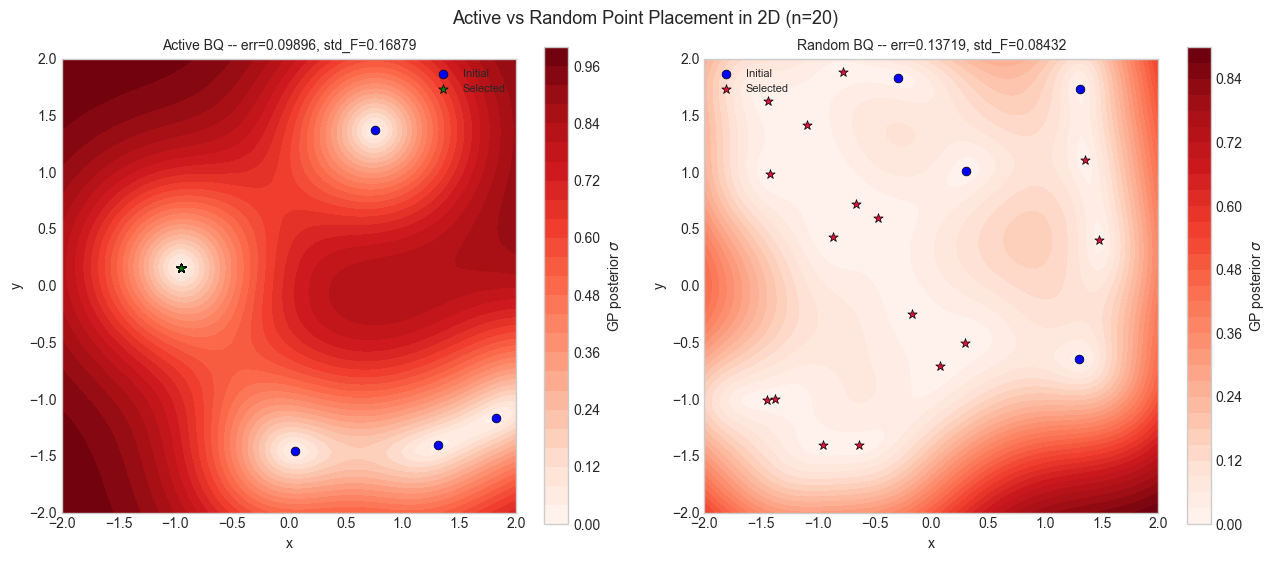

In [15]:
n_init_2d = 4
n_active_2d = 16
rng_2d = np.random.default_rng(10)

X_init_2d = rng_2d.uniform(-2, 2, size=(n_init_2d, 2))
y_init_2d = f1_gauss_bump(X_init_2d)

cand_1d = np.linspace(-1.9, 1.9, 25)
cx, cy = np.meshgrid(cand_1d, cand_1d)
candidates_2d = np.column_stack([cx.ravel(), cy.ravel()])

kernel_act = RBFKernel(lengthscale=1.0, variance=1.0)
config_act = BQConfig(noise=0.0, jitter=1e-7, mc_samples_mean=2048, mc_samples_var=4096)

model_act_2d = BayesianQuadratureModel(kernel_act, measure_uniform_2d, config=config_act)
model_act_2d.fit(X_init_2d.copy(), y_init_2d.copy())

active_errors = []
mean_F, var_F = model_act_2d.integral_posterior()
active_errors.append(abs(mean_F - TRUE_F1))

for _ in range(n_active_2d):
    selector = ActiveBQSelector(model_act_2d)
    best_idx, _, _ = selector.greedy_select(candidates_2d)
    x_new = candidates_2d[best_idx:best_idx + 1]
    y_new = f1_gauss_bump(x_new)
    model_act_2d.update(x_new, y_new)
    mf, vf = model_act_2d.integral_posterior()
    active_errors.append(abs(mf - TRUE_F1))

X_active_final_2d = model_act_2d.dataset.X

# Random comparison with same budget
X_rand_2d = rng_2d.uniform(-2, 2, size=(n_init_2d + n_active_2d, 2))
y_rand_2d = f1_gauss_bump(X_rand_2d)

model_rand_2d = BayesianQuadratureModel(kernel_act, measure_uniform_2d, config=config_act)
model_rand_2d.fit(X_rand_2d, y_rand_2d)

# Predict posterior uncertainty for both
_, gp_var_active = model_act_2d.predict(XY_fine)
_, gp_var_random = model_rand_2d.predict(XY_fine)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, X_pts, gp_v, title, color in [
    (axes[0], X_active_final_2d, gp_var_active, 'Active BQ', 'green'),
    (axes[1], X_rand_2d, gp_var_random, 'Random BQ', 'crimson'),
]:
    std_map = np.sqrt(np.maximum(gp_v, 0.0)).reshape(xx_f.shape)
    c = ax.contourf(xx_f, yy_f, std_map, levels=30, cmap='Reds')
    plt.colorbar(c, ax=ax, label=r'GP posterior $\sigma$')

    n_init_pts = n_init_2d
    ax.scatter(X_pts[:n_init_pts, 0], X_pts[:n_init_pts, 1],
               c='blue', s=40, marker='o', edgecolors='k', linewidths=0.5, label='Initial', zorder=5)
    ax.scatter(X_pts[n_init_pts:, 0], X_pts[n_init_pts:, 1],
               c=color, s=50, marker='*', edgecolors='k', linewidths=0.5, label='Selected', zorder=6)

    mf, vf = (model_act_2d if 'Active' in title else model_rand_2d).integral_posterior()
    ax.set_title(f'{title} -- err={abs(mf - TRUE_F1):.5f}, std_F={np.sqrt(max(vf,0)):.5f}', fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

plt.suptitle(f'Active vs Random Point Placement in 2D (n={n_init_2d + n_active_2d})', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Error Trajectory: Active vs Random in 2D

We now compare how the absolute integration error evolves for active and random BQ as points are added sequentially.

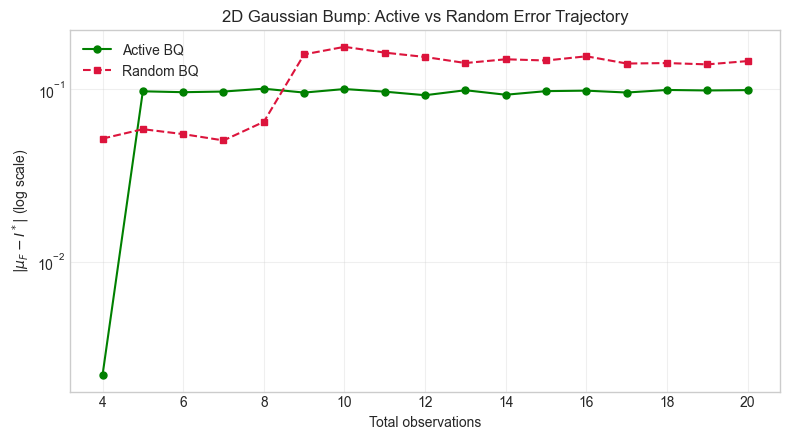

In [16]:
# Random trajectory
random_errors = []
for n in range(n_init_2d, n_init_2d + n_active_2d + 1):
    mr = BayesianQuadratureModel(kernel_act, measure_uniform_2d, config=config_act)
    mr.fit(X_rand_2d[:n], y_rand_2d[:n])
    mf, _ = mr.integral_posterior()
    random_errors.append(abs(mf - TRUE_F1))

pts_range = list(range(n_init_2d, n_init_2d + n_active_2d + 1))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(pts_range, active_errors, 'o-', color='green', lw=1.5, ms=5, label='Active BQ')
ax.semilogy(pts_range, random_errors, 's--', color='crimson', lw=1.5, ms=5, label='Random BQ')
ax.set_xlabel('Total observations')
ax.set_ylabel(r'$|\mu_F - I^*|$ (log scale)')
ax.set_title('2D Gaussian Bump: Active vs Random Error Trajectory')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Key Takeaways

1. **BQ extends naturally to 2D.** The RBF kernel computes pairwise distances in $\mathbb{R}^d$, so no code changes are needed — only the data shapes change. The `BayesianQuadratureModel` class handles arbitrary dimension seamlessly.

2. **BQ outperforms MC at small budgets for smooth functions.** When the integrand is well-matched by the kernel prior (smooth, stationary), BQ achieves significantly lower error than Monte Carlo with the same number of evaluations. The advantage is particularly clear in the 10–60 point range.

3. **The GP posterior uncertainty map is informative.** Regions far from observed points have high posterior standard deviation, exactly as expected. This map can be used to diagnose under-sampled regions.

4. **Active sampling produces better point layouts.** In 2D, the active strategy places points in a space-filling pattern biased toward regions important for the integral. This results in lower posterior variance and typically lower error compared to random placement.

5. **Kernel choice becomes more critical in higher dimensions.** With fewer points per unit volume, the GP must extrapolate more aggressively. A well-chosen lengthscale is essential — too short and the GP cannot generalize between points; too long and it over-smooths.

6. **Oscillatory functions are harder.** The symmetric-integrand experiment ($f_3$) shows that when the integral is zero by symmetry, both BQ and MC produce small errors, but the GP posterior may not reflect this symmetry unless the observation points are themselves symmetric.